<span style="color:gray; font-size:smaller;">Written by Salil Deshpande</span>

When working with large collections of motifs, one common goal you may have is to cluster the motifs into order to identify groups of similar and distinct motifs. This tutorial will focus on the functionality that MotifCompendium offers to assist with clustering motifs and judging the quality of a particular clustering of motifs.

Let's get started!

We will begin by importing the packages we will need.

In [1]:
import gdown
import matplotlib.pyplot as plt
import numpy as np

import MotifCompendium
import MotifCompendium.utils.analysis as utils_analysis
import MotifCompendium.utils.plotting as utils_plotting

This tutorial will be written as if we had access to a 12GB GPU. If you want to run this tutorial yourself but do not have access to a GPU then set `use_gpu=False` and do not set the `max_chunk` parameter.

In [2]:
MotifCompendium.set_compute_options(max_cpus=4, use_gpu=True, max_chunk=1152)

Note that clustering itself does not require or utilize the GPU, but computing a cluster-averaged MotifCompendium, which is covered in Section 4, can make use of GPU.

We will also download all the data that we need for this tutorial.

In [3]:
cardiomyocyte_file_id = "1iAeA2dczPsDEhDp3d4qsVt0oBtU9X07R"
cardiomyocyte_file_url = f"https://drive.google.com/uc?id={cardiomyocyte_file_id}"
cardiomyocyte_output_file = "tutorial_data/cardiomyocyte_modisco_output.h5"
gdown.download(cardiomyocyte_file_url, cardiomyocyte_output_file, quiet=False)

endothelial_file_id = "1Na2-QIa5davufwc_R4Awa87MQf6zBhR4"
endothelial_file_url = f"https://drive.google.com/uc?id={endothelial_file_id}"
endothelial_output_file = "tutorial_data/endothelial_modisco_output.h5"
gdown.download(endothelial_file_url, endothelial_output_file, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1iAeA2dczPsDEhDp3d4qsVt0oBtU9X07R
From (redirected): https://drive.google.com/uc?id=1iAeA2dczPsDEhDp3d4qsVt0oBtU9X07R&confirm=t&uuid=1ec58169-7465-491e-a880-0a8bed2bd776
To: /users/salil512/experiments/MotifCompendium/tutorials/tutorial_data/cardiomyocyte_modisco_output.h5
100%|██████████| 484M/484M [00:04<00:00, 102MB/s]  
Downloading...
From (original): https://drive.google.com/uc?id=1Na2-QIa5davufwc_R4Awa87MQf6zBhR4
From (redirected): https://drive.google.com/uc?id=1Na2-QIa5davufwc_R4Awa87MQf6zBhR4&confirm=t&uuid=21ea7fb1-fa83-422a-8c1a-08acefe5155c
To: /users/salil512/experiments/MotifCompendium/tutorials/tutorial_data/endothelial_modisco_output.h5
100%|██████████| 241M/241M [00:02<00:00, 91.6MB/s] 


'tutorial_data/endothelial_modisco_output.h5'

# Part 1 - Clustering Options

In this tutorial, we will begin by building a MotifCompendium in the same way that it was built in the first tutorial.

In [4]:
modisco_dict = {
    "cardiomyocyte": "tutorial_data/cardiomyocyte_modisco_output.h5",
    "endothelial": "tutorial_data/endothelial_modisco_output.h5"
}
mc = MotifCompendium.build_from_modisco(modisco_dict)
mc

,name,num_seqlets,model,posneg,avg_contrib,avg_dist_from_summit
0,cardiomyocyte-pos.pattern_0,24730,cardiomyocyte,pos,0.629150,15.721553
1,cardiomyocyte-pos.pattern_1,23251,cardiomyocyte,pos,0.421469,33.662853
2,cardiomyocyte-pos.pattern_10,4122,cardiomyocyte,pos,0.383973,33.419699
3,cardiomyocyte-pos.pattern_11,4008,cardiomyocyte,pos,0.351602,36.965818
4,cardiomyocyte-pos.pattern_12,3352,cardiomyocyte,pos,0.453516,42.597554
...,...,...,...,...,...,...
83,endothelial-pos.pattern_5,3338,endothelial,pos,0.479641,37.803475
84,endothelial-pos.pattern_6,2977,endothelial,pos,0.437019,35.074236
85,endothelial-pos.pattern_7,2358,endothelial,pos,0.469403,37.488550
86,endothelial-pos.pattern_8,2115,endothelial,pos,0.529135,51.907329


As was shown in the first tutorial, you can cluster the motifs in a MotifCompendium object by simply calling the `.cluster()` method of a MotifCompendium object.

In [5]:
mc.cluster()
mc

,name,num_seqlets,model,posneg,avg_contrib,avg_dist_from_summit,cluster
0,cardiomyocyte-pos.pattern_0,24730,cardiomyocyte,pos,0.629150,15.721553,3
1,cardiomyocyte-pos.pattern_1,23251,cardiomyocyte,pos,0.421469,33.662853,8
2,cardiomyocyte-pos.pattern_10,4122,cardiomyocyte,pos,0.383973,33.419699,12
3,cardiomyocyte-pos.pattern_11,4008,cardiomyocyte,pos,0.351602,36.965818,4
4,cardiomyocyte-pos.pattern_12,3352,cardiomyocyte,pos,0.453516,42.597554,32
...,...,...,...,...,...,...,...
83,endothelial-pos.pattern_5,3338,endothelial,pos,0.479641,37.803475,1
84,endothelial-pos.pattern_6,2977,endothelial,pos,0.437019,35.074236,13
85,endothelial-pos.pattern_7,2358,endothelial,pos,0.469403,37.488550,16
86,endothelial-pos.pattern_8,2115,endothelial,pos,0.529135,51.907329,64


This adds a column to the MotifCompendium called `cluster` that contains integers. Motifs with the same value in the `cluster` column have been clustered together.

**While the `.cluster()` method can be called without providing any arguments, there are always 3 arguments that it is always highly recommended to provide**:

- `algorithm`: Which clustering algorithm to use.
- `similarity_threshold`: The similarity score above which two motifs should be considered similar.
- `save_name`: The column name that clustering results should be saved to.

When specifying the `algorithm` argument, you must select amongst a selection of supported clustering algorithms. The possible algorithms and their characteristics will be discussed in in more detail in [Section 3](#3---go-algorithm-by-algorithm). For the rest of the tutorial until then, however, we will be not be providing an `algorithm` argument and will be using the default clustering algorithm, which is the Leiden community detection algorithm.

When specifying the `similarity_threshold` argument, you must specify a floating point number between 0 and 1. Ideally, this value should be set after having a sense of which similarity threshold is most appropriate for your task. For more details on how to best set this value, please review [Tutorial 1](1_basic_usage.ipynb).

The `save_name` value should be any string specifying the column name to which clustering results should be saved to. If `save_name` refers to a column that already exists in the MotifCompendium then that column's values will be overridden. Otherwise, a new column corresponding to `save_name` will be added.

When you call the `.cluster()` method, the `.similarity` attribute of the calling MotifCompendium is used to create a graph of motifs, where each node is a motif and two motifs have an edge betweeen them if their similarity is above the specified `similarity_threshold`. Then, graph clustering and community detection algorithms are applied to the resulting graph to identify clusters of motifs.

In general, a higher `similarity_threshold` will lead to a stricter clustering with more clusters, and a lower `similarity_threshold` will lead to a looser clustering with fewer clusters.

The clustering algorithms will always output clustering values between 0 and C-1 where `C` is the number of clusters that were identified.

Below is an example of how setting a variety of similarity thresholds will lead to a different number of clusters.

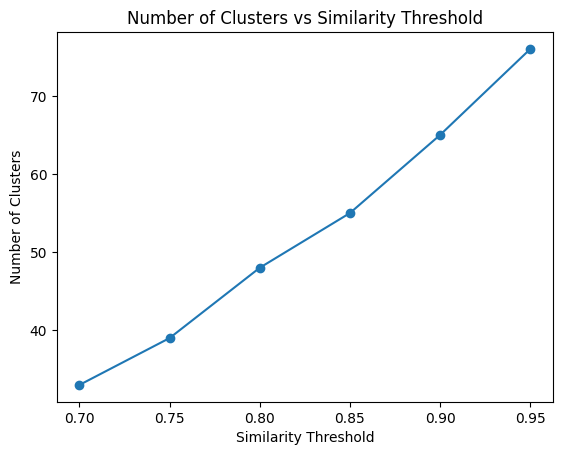

In [6]:
similarity_thresholds = [0.7, 0.75, 0.8, 0.85, 0.9, 0.95]
num_clusters = []
for similarity_threshold in similarity_thresholds:
    mc.cluster(similarity_threshold=similarity_threshold, save_name=f"cluster_{similarity_threshold}")
    num_clusters.append(max(mc[f"cluster_{similarity_threshold}"])+1) # Number of clusters is max cluster id + 1

plt.plot(similarity_thresholds, num_clusters, marker='o')
plt.xlabel("Similarity Threshold")
plt.ylabel("Number of Clusters")
plt.title("Number of Clusters vs Similarity Threshold")
plt.show()

We can see how the number of clusters increases with the similarity threshold.

Also, notice below how setting the `save_name` argument creates different columns in the MotifCompendium.

In [7]:
mc

,name,num_seqlets,model,posneg,avg_contrib,avg_dist_from_summit,cluster,cluster_0.7,cluster_0.75,cluster_0.8,cluster_0.85,cluster_0.9,cluster_0.95
0,cardiomyocyte-pos.pattern_0,24730,cardiomyocyte,pos,0.629150,15.721553,3,13,11,15,19,3,0
1,cardiomyocyte-pos.pattern_1,23251,cardiomyocyte,pos,0.421469,33.662853,8,8,6,5,6,8,1
2,cardiomyocyte-pos.pattern_10,4122,cardiomyocyte,pos,0.383973,33.419699,12,2,14,13,21,12,18
3,cardiomyocyte-pos.pattern_11,4008,cardiomyocyte,pos,0.351602,36.965818,4,14,13,14,20,4,19
4,cardiomyocyte-pos.pattern_12,3352,cardiomyocyte,pos,0.453516,42.597554,32,0,12,11,9,32,16
...,...,...,...,...,...,...,...,...,...,...,...,...,...
83,endothelial-pos.pattern_5,3338,endothelial,pos,0.479641,37.803475,1,1,1,1,2,1,6
84,endothelial-pos.pattern_6,2977,endothelial,pos,0.437019,35.074236,13,5,19,21,15,13,5
85,endothelial-pos.pattern_7,2358,endothelial,pos,0.469403,37.488550,16,11,15,16,17,16,8
86,endothelial-pos.pattern_8,2115,endothelial,pos,0.529135,51.907329,64,32,18,47,54,64,75


The `.cluster()` method also contains 3 very useful optional arguments for performing more complex and sophisticated motif clustering. These arguments are `cluster_within`, `cluster_on`, and `cluster_within_on`.

The `cluster_within` argument takes in a column name in the calling MotifCompendium. The `cluster_within` column is treated as a clustering/grouping itself and those clusters are sub-clustered. That is, we are identifying clusters *within* a previously-defined grouping. Setting the `cluster_within` option guarantees that if two motifs were not in the same `cluster_within` grouping originally, then they will not be in the same clustering afterwards: `mc.metadata.iloc[i, cluster_within] != mc.metadata.iloc[j, cluster_within]` implies `mc.metadata.iloc[i, save_name] != mc.metadata.iloc[j, save_name]`.

Suppose you wanted to find clusters within cardiomyocytes and within endothelial cells but did not want to mix motifs from the two models. That can be done with `cluster_within`:

In [8]:
# Cluster within model
mc.cluster(similarity_threshold=0.95, save_name="cluster_within_model", cluster_within="model")
# Confirm that there are no mixed clusters
for cluster_id in mc["cluster_within_model"]:
    assert len(set(mc[mc["cluster_within_model"] == cluster_id]["model"])) == 1
mc

,name,num_seqlets,model,posneg,avg_contrib,avg_dist_from_summit,cluster,cluster_0.7,cluster_0.75,cluster_0.8,cluster_0.85,cluster_0.9,cluster_0.95,cluster_within_model
0,cardiomyocyte-pos.pattern_0,24730,cardiomyocyte,pos,0.629150,15.721553,3,13,11,15,19,3,0,2
1,cardiomyocyte-pos.pattern_1,23251,cardiomyocyte,pos,0.421469,33.662853,8,8,6,5,6,8,1,1
2,cardiomyocyte-pos.pattern_10,4122,cardiomyocyte,pos,0.383973,33.419699,12,2,14,13,21,12,18,6
3,cardiomyocyte-pos.pattern_11,4008,cardiomyocyte,pos,0.351602,36.965818,4,14,13,14,20,4,19,3
4,cardiomyocyte-pos.pattern_12,3352,cardiomyocyte,pos,0.453516,42.597554,32,0,12,11,9,32,16,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83,endothelial-pos.pattern_5,3338,endothelial,pos,0.479641,37.803475,1,1,1,1,2,1,6,82
84,endothelial-pos.pattern_6,2977,endothelial,pos,0.437019,35.074236,13,5,19,21,15,13,5,83
85,endothelial-pos.pattern_7,2358,endothelial,pos,0.469403,37.488550,16,11,15,16,17,16,8,84
86,endothelial-pos.pattern_8,2115,endothelial,pos,0.529135,51.907329,64,32,18,47,54,64,75,85


The `cluster_on` argument takes in a column name in the calling MotifCompendium. The `cluster_on` column is treated as a clustering/grouping itself and those clusters are used as constituents for another round of clustering. That is, we are identifying clusters *on top of* a previously-defined grouping. Setting the `cluster_on` option guarantees that if two motifs were in the same `cluster_on` grouping originally, then they will be in the same clustering afterwards: `mc.metadata.iloc[i, cluster_on] == mc.metadata.iloc[j, cluster_on]` implies `mc.metadata.iloc[i, save_name] == mc.metadata.iloc[j, save_name]`.

Suppose you wanted to do a strict round of clustering (at 0.95 similarity) and then wanted to do a looser round of clustering (at 0.85 similarity) on top of that. That can be done with `cluster_on`:

In [9]:
# Cluster on cluster_0.95
mc.cluster(similarity_threshold=0.85, save_name="cluster_0.95_then_0.85", cluster_on="cluster_0.95")
# Confirm that all clusters are built on top of cluster_0.95
for cluster_id in mc["cluster_0.95"]:
    assert len(set(mc[mc["cluster_0.95"] == cluster_id]["cluster_0.95_then_0.85"])) == 1
mc

,name,num_seqlets,model,posneg,avg_contrib,avg_dist_from_summit,cluster,cluster_0.7,cluster_0.75,cluster_0.8,cluster_0.85,cluster_0.9,cluster_0.95,cluster_within_model,cluster_0.95_then_0.85
0,cardiomyocyte-pos.pattern_0,24730,cardiomyocyte,pos,0.629150,15.721553,3,13,11,15,19,3,0,2,8
1,cardiomyocyte-pos.pattern_1,23251,cardiomyocyte,pos,0.421469,33.662853,8,8,6,5,6,8,1,1,4
2,cardiomyocyte-pos.pattern_10,4122,cardiomyocyte,pos,0.383973,33.419699,12,2,14,13,21,12,18,6,16
3,cardiomyocyte-pos.pattern_11,4008,cardiomyocyte,pos,0.351602,36.965818,4,14,13,14,20,4,19,3,15
4,cardiomyocyte-pos.pattern_12,3352,cardiomyocyte,pos,0.453516,42.597554,32,0,12,11,9,32,16,4,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83,endothelial-pos.pattern_5,3338,endothelial,pos,0.479641,37.803475,1,1,1,1,2,1,6,82,0
84,endothelial-pos.pattern_6,2977,endothelial,pos,0.437019,35.074236,13,5,19,21,15,13,5,83,19
85,endothelial-pos.pattern_7,2358,endothelial,pos,0.469403,37.488550,16,11,15,16,17,16,8,84,18
86,endothelial-pos.pattern_8,2115,endothelial,pos,0.529135,51.907329,64,32,18,47,54,64,75,85,56


The `cluster_within_on` argument takes in a tuple of two column names in the calling MotifCompendium. The tuple `cluster_within_on` is treated as a pair `(cluster_within, cluster_on)`, both of which are treated as clustering/groupings themselves. Clustering is done *within* `cluster_within_on[0]`, and within that *on top of* `cluster_within_on[1]` such that both: `mc.metadata.iloc[i, cluster_within_on[0]] != mc.metadata.iloc[j, cluster_within_on[0]]` implies `mc.metadata.iloc[i, save_name] != mc.metadata.iloc[j, save_name]` and `(mc.metadata.iloc[i, cluster_within_on[0]] == mc.metadata.iloc[j, cluster_within_on[0]]) and (mc.metadata.iloc[i, cluster_within_on[1]] == mc.metadata.iloc[j, cluster_within_on[1]])` implies `mc.metadata.iloc[i, save_name] == mc.metadata.iloc[j, save_name]`.

Suppose you wanted to do a second round of clustering on top of already-defined model-specific clusters. That can be done with `cluster_within_on`:

In [10]:
# Cluster within model on cluster_within_model
mc.cluster(similarity_threshold=0.85, save_name="cluster_within_model_v2", cluster_within_on=("model", "cluster_within_model"))
# Confirm that clustering within cluster_within_on[0] is satisfied
for cluster_id in mc["cluster_within_model_v2"]:
    assert len(set(mc[mc["cluster_within_model_v2"] == cluster_id]["model"])) == 1
# Confirm that within cluster_within_on[0], clustering on cluster_within_on[1] is satisfied
for cluster_within_id in mc["model"]:
    for cluster_on_id in set(mc[mc["model"] == cluster_within_id]["cluster_within_model"]):
        assert len(set(mc[mc["cluster_within_model"] == cluster_on_id]["cluster_within_model_v2"])) == 1
mc

,name,num_seqlets,model,posneg,avg_contrib,avg_dist_from_summit,cluster,cluster_0.7,cluster_0.75,cluster_0.8,cluster_0.85,cluster_0.9,cluster_0.95,cluster_within_model,cluster_0.95_then_0.85,cluster_within_model_v2
0,cardiomyocyte-pos.pattern_0,24730,cardiomyocyte,pos,0.629150,15.721553,3,13,11,15,19,3,0,2,8,16
1,cardiomyocyte-pos.pattern_1,23251,cardiomyocyte,pos,0.421469,33.662853,8,8,6,5,6,8,1,1,4,4
2,cardiomyocyte-pos.pattern_10,4122,cardiomyocyte,pos,0.383973,33.419699,12,2,14,13,21,12,18,6,16,7
3,cardiomyocyte-pos.pattern_11,4008,cardiomyocyte,pos,0.351602,36.965818,4,14,13,14,20,4,19,3,15,3
4,cardiomyocyte-pos.pattern_12,3352,cardiomyocyte,pos,0.453516,42.597554,32,0,12,11,9,32,16,4,17,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83,endothelial-pos.pattern_5,3338,endothelial,pos,0.479641,37.803475,1,1,1,1,2,1,6,82,0,2
84,endothelial-pos.pattern_6,2977,endothelial,pos,0.437019,35.074236,13,5,19,21,15,13,5,83,19,65
85,endothelial-pos.pattern_7,2358,endothelial,pos,0.469403,37.488550,16,11,15,16,17,16,8,84,18,66
86,endothelial-pos.pattern_8,2115,endothelial,pos,0.529135,51.907329,64,32,18,47,54,64,75,85,56,67


**Note: The `cluster_within_on` behavior cannot be recapiulated by just setting `cluster_within` and `cluster_on` because only one of `cluster_within`, `cluster_on`, or `cluster_within_on` can be set at a time.**

`cluster_on` and `cluster_within_on` work by averaging motifs in the clusterings specified by `cluster_on` and `cluster_within_on[1]` and then clustering those *cluster-average* motifs. These averages are computed by weighing all motifs in the group equally. However, it is possible to do a weighted sum by setting the `cluster_on_weight` argument. The `cluster_on_weight` argument takes in a column name of the calling MotifCompendium and uses the values in the specified column as weights to perform a weighted sum of the motifs. A common use case for this would be if you want to weigh motifs by how frequently they appear.

Below, we will perform a weighted `cluster_on` and `cluster_within_on` by setting `cluster_on_weight` to be `num_seqlets`.

In [11]:
# Weighted cluster on cluster_0.95
mc.cluster(similarity_threshold=0.85, save_name="weighted_cluster_0.95_then_0.85", cluster_on="cluster_0.95", cluster_on_weight="num_seqlets")
# Weighted cluster within model on cluster_within_model
mc.cluster(similarity_threshold=0.85, save_name="cluster_within_model_v2", cluster_within_on=("model", "cluster_within_model"), cluster_on_weight="num_seqlets")
mc

,name,num_seqlets,model,posneg,avg_contrib,avg_dist_from_summit,cluster,cluster_0.7,cluster_0.75,cluster_0.8,cluster_0.85,cluster_0.9,cluster_0.95,cluster_within_model,cluster_0.95_then_0.85,cluster_within_model_v2,weighted_cluster_0.95_then_0.85
0,cardiomyocyte-pos.pattern_0,24730,cardiomyocyte,pos,0.629150,15.721553,3,13,11,15,19,3,0,2,8,16,8
1,cardiomyocyte-pos.pattern_1,23251,cardiomyocyte,pos,0.421469,33.662853,8,8,6,5,6,8,1,1,4,4,4
2,cardiomyocyte-pos.pattern_10,4122,cardiomyocyte,pos,0.383973,33.419699,12,2,14,13,21,12,18,6,16,7,16
3,cardiomyocyte-pos.pattern_11,4008,cardiomyocyte,pos,0.351602,36.965818,4,14,13,14,20,4,19,3,15,3,15
4,cardiomyocyte-pos.pattern_12,3352,cardiomyocyte,pos,0.453516,42.597554,32,0,12,11,9,32,16,4,17,6,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83,endothelial-pos.pattern_5,3338,endothelial,pos,0.479641,37.803475,1,1,1,1,2,1,6,82,0,2,0
84,endothelial-pos.pattern_6,2977,endothelial,pos,0.437019,35.074236,13,5,19,21,15,13,5,83,19,65,19
85,endothelial-pos.pattern_7,2358,endothelial,pos,0.469403,37.488550,16,11,15,16,17,16,8,84,18,66,18
86,endothelial-pos.pattern_8,2115,endothelial,pos,0.529135,51.907329,64,32,18,47,54,64,75,85,56,67,56


The `.cluster()` method has an additional argument called `largest_clusters_first`. When `largest_clusters_first` is set to `True`, the cluster with the most constituents is defined as Cluster 0, the cluster with the second most number of constituents is defined as Cluster 1, etc. When `largest_clusters_first` is set to `False`, the order of the clusters is based on the underlying algorithm. By default, `largest_clusters_first` is set to True, but you can set `largest_clusters_first=False` like in the example below.

In [12]:
mc.cluster(similarity_threshold=0.85, save_name="cluster_within_model_v2_unordered", cluster_within_on=("model", "cluster_within_model"), cluster_on_weight="num_seqlets", largest_clusters_first=False)
mc

,name,num_seqlets,model,posneg,avg_contrib,avg_dist_from_summit,cluster,cluster_0.7,cluster_0.75,cluster_0.8,cluster_0.85,cluster_0.9,cluster_0.95,cluster_within_model,cluster_0.95_then_0.85,cluster_within_model_v2,weighted_cluster_0.95_then_0.85,cluster_within_model_v2_unordered
0,cardiomyocyte-pos.pattern_0,24730,cardiomyocyte,pos,0.629150,15.721553,3,13,11,15,19,3,0,2,8,16,8,11
1,cardiomyocyte-pos.pattern_1,23251,cardiomyocyte,pos,0.421469,33.662853,8,8,6,5,6,8,1,1,4,4,4,9
2,cardiomyocyte-pos.pattern_10,4122,cardiomyocyte,pos,0.383973,33.419699,12,2,14,13,21,12,18,6,16,7,16,1
3,cardiomyocyte-pos.pattern_11,4008,cardiomyocyte,pos,0.351602,36.965818,4,14,13,14,20,4,19,3,15,3,15,10
4,cardiomyocyte-pos.pattern_12,3352,cardiomyocyte,pos,0.453516,42.597554,32,0,12,11,9,32,16,4,17,6,17,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83,endothelial-pos.pattern_5,3338,endothelial,pos,0.479641,37.803475,1,1,1,1,2,1,6,82,0,2,0,35
84,endothelial-pos.pattern_6,2977,endothelial,pos,0.437019,35.074236,13,5,19,21,15,13,5,83,19,65,19,65
85,endothelial-pos.pattern_7,2358,endothelial,pos,0.469403,37.488550,16,11,15,16,17,16,8,84,18,66,18,66
86,endothelial-pos.pattern_8,2115,endothelial,pos,0.529135,51.907329,64,32,18,47,54,64,75,85,56,67,56,67


# Part 2 - Judging Clustering Quality And Success

After clustering motifs, an important next step may be to try and evaluate how successful the clustering was. This can help determine if clustering needs to be repeated or refined.

In this section, we will present the various tools and utilities available in MotifCompendium to help assess clustering success.

Let's begin by discussing fundamental challenges in clustering, in general.

When performing any clustering, there are often two objectives that one has to balance. First, you want to make sure that clusters are homogenous. If they are not, then your clusters are too broad and can be further refined. Second, you want to make sure that there aren't two separate clusters that actually contain the same items. If that is not true, then your clusters are too fine-grained and can be combined.

These two objectives are actually competing objectives, since fixing one can often mean making the other worse. For instance, if I find that my clusters are too coarse and I try to sub-cluster them, I run the risk of breaking them apart too much and creating sub-clusters which can actually be combined. On the other hand, if I have clusters that are too fine-grained, I can try and combine them. However, doing so runs the risk of combining clusters that shouldn't be together.

MotifCompendium attempts to measure these two objectives through the notion of *clustering quality*. The *quality* of a clustering is measured in two ways:

- Intra-cluster lowest internal similarity: This quantity, which is computed per cluster, is the lowest pairwise similarity amongst all motif pairs within the cluster. That is, $$LIS_c = \min \{s_{i, j} | cluster(i) = cluster(j) = c\}$$
- Inter-cluster highest external similarity: This quantity, which is computed per pair of clusters, is the highest similarity among pairs of motifs where one motif is in one cluster and the other motif is in the other cluster. That is, $$HES_{c_a, c_b} = \max \{s_{i, j} | cluster(i) = c_a,  cluster(j) = c_b\}$$

If you find that the lowest internal similarity of a cluster is too low, that indicates that the cluster contains disparate motifs and is too coarse-grained.

If you find that the highest external similarity of cluster is too high, that indicates that either (1) a misassignment has occurred and a motif from one cluster actually belongs to another cluster, or (2) the two clusters contain the same things and can be merged. Note that these two situations can be distinguished by conforming if the two clusters have high lowest internal similarities. If they do, then it is likely that they can be combined; if not, then there is probably a misassignment that has occurred.

For a given clustering of motifs, the quality of that clustering can be computed using the `.clustering_quality()` method. The `.clustering_quality()` method of a MotifCompendium takes in a string denoting a column in the MotifCompendium that has clustering information and computes the quality of the MotifCompendium with respect to that clustering.

In [13]:
quality = mc.clustering_quality("cluster_within_model_v2")
quality

,0,1,2,3,4,5,6,7,8,9,...,59,60,61,62,63,64,65,66,67,68
0,0.881372,0.395270,0.458412,0.541545,0.627148,0.634150,0.848302,0.473325,0.515624,0.655419,...,0.404944,0.526771,0.823286,0.483000,0.866266,0.390841,0.468890,0.460614,0.798687,0.459005
1,0.395270,0.870864,0.434129,0.448765,0.424641,0.297929,0.330351,0.497113,0.529628,0.500494,...,0.592071,0.297032,0.601638,0.357233,0.318580,0.423439,0.782270,0.489754,0.325915,0.324207
2,0.458412,0.434129,0.898826,0.452105,0.426108,0.296032,0.413975,0.669318,0.313332,0.517635,...,0.874749,0.267755,0.545374,0.505352,0.427276,0.314682,0.451889,0.537270,0.366632,0.298781
3,0.541545,0.448765,0.452105,0.926124,0.382663,0.349350,0.468855,0.568848,0.371736,0.481864,...,0.457819,0.300438,0.523796,0.364307,0.457448,0.358931,0.554770,0.460949,0.432536,0.300944
4,0.627148,0.424641,0.426108,0.382663,0.870299,0.620388,0.534760,0.558766,0.365501,0.807343,...,0.354247,0.537310,0.484040,0.531943,0.635967,0.340721,0.540950,0.377406,0.530455,0.356212
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64,0.390841,0.423439,0.314682,0.358931,0.340721,0.396823,0.473038,0.464766,0.399259,0.358359,...,0.342700,0.400400,0.489079,0.360646,0.282775,1.000000,0.326138,0.621185,0.355829,0.408607
65,0.468890,0.782270,0.451889,0.554770,0.540950,0.438791,0.396735,0.437592,0.340724,0.613295,...,0.573503,0.381179,0.387819,0.406620,0.414646,0.326138,1.000000,0.244221,0.398780,0.358920
66,0.460614,0.489754,0.537270,0.460949,0.377406,0.410012,0.706172,0.650716,0.459959,0.495284,...,0.414252,0.355132,0.391504,0.438497,0.374957,0.621185,0.244221,1.000000,0.458372,0.494106
67,0.798687,0.325915,0.366632,0.432536,0.530455,0.614867,0.662640,0.496769,0.434575,0.539790,...,0.403223,0.577111,0.665136,0.371065,0.709734,0.355829,0.398780,0.458372,1.000000,0.391466


The quality produced by `.clustering_quality()` is a `pd.DataFrame` whose rows and columns are indexed by the cluster names. Values along the diagonal are the intra-cluster lowest internal similarities and off-diagonal values are the inter-cluster highest internal similarities.

In [14]:
print(f"Cluster 0 lowest internal similarity: {quality.loc[0, 0]}")
print(f"Cluster 2/Cluster 7 highest external similarity: {quality.loc[2, 7]}")

Cluster 0 lowest internal similarity: 0.8813718557357788
Cluster 2/Cluster 7 highest external similarity: 0.669318437576294


If you want the quality as a `np.ndarray`, call the `to_numpy()` method on the quality.

In [15]:
quality_np = quality.to_numpy()
quality_np

array([[0.88137186, 0.39527026, 0.4584122 , ..., 0.46061379, 0.79868674,
        0.45900512],
       [0.39527026, 0.87086391, 0.43412882, ..., 0.48975396, 0.3259151 ,
        0.32420737],
       [0.4584122 , 0.43412882, 0.8988263 , ..., 0.53727019, 0.36663169,
        0.29878125],
       ...,
       [0.46061379, 0.48975396, 0.53727019, ..., 1.        , 0.45837194,
        0.49410552],
       [0.79868674, 0.3259151 , 0.36663169, ..., 0.45837194, 1.        ,
        0.39146593],
       [0.45900512, 0.32420737, 0.29878125, ..., 0.49410552, 0.39146593,
        1.        ]], shape=(69, 69))

The `.clustering_quality()` method can also be provided the `with_stats` flag, which is `False` by default. When `with_stats` is set to True, additional columns are added on which summarize the quality information per cluster. These columns are:

- `lowest_internal_similarity`: The per-cluster lowest internal similarity.
- `lowest_internal_similarity_motif1_name`: The name of one of the motifs contributing to the lowest internal similarity in that cluster.
- `lowest_internal_similarity_motif1_motif`: The actual motif `np.ndarray` of one of the motifs contributing to the lowest internal similarity in that cluster.
- `lowest_internal_similarity_motif2_name`: The name of the other motif contributing to the lowest internal similarity in that cluster.
- `lowest_internal_similarity_motif2_motif`: The actual motif `np.ndarray` of the other motif contributing to the lowest internal similarity in that cluster.
- `highest_external_similarity`: Per cluster, the highest external similarity across all other clusters.
- `highest_external_similarity_cluster`: The cluster ID of the other cluster with which the highest external similarity was achieved.
- `highest_external_similarity_motif_name`: The name of motif with which the highest external similarity was achieved.
- `highest_external_similarity_motif_motif`: The actual motif `np.ndarray` of the motif with which the highest external similarity was achieved.

In [16]:
quality = mc.clustering_quality("cluster_within_model_v2", with_stats=True)
quality

,0,1,2,3,4,5,6,7,8,9,...,68,lowest_internal_similarity,lowest_internal_similarity_motif1_name,lowest_internal_similarity_motif1_motif,lowest_internal_similarity_motif2_name,lowest_internal_similarity_motif2_motif,highest_external_similarity,highest_external_similarity_cluster,highest_external_similarity_motif_name,highest_external_similarity_motif_motif
0,0.881372,0.395270,0.458412,0.541545,0.627148,0.634150,0.848302,0.473325,0.515624,0.655419,...,0.459005,0.881372,endothelial-pos.pattern_20,"[[0.0007314816759067754, 0.0019333257212078999...",endothelial-pos.pattern_21,"[[0.0010216552597795436, 0.0006055713479383281...",0.910510,54,endothelial-pos.pattern_27,"[[0.00024876082081392784, 0.000618725901551763..."
1,0.395270,0.870864,0.434129,0.448765,0.424641,0.297929,0.330351,0.497113,0.529628,0.500494,...,0.324207,0.870864,endothelial-pos.pattern_34,"[[0.0001264877982584452, 0.0001506543244237796...",endothelial-pos.pattern_41,"[[0.0013918591166203022, 0.0001221165273412170...",0.782270,65,endothelial-pos.pattern_6,"[[-3.2812436448836683e-05, 0.00302789380848606..."
2,0.458412,0.434129,0.898826,0.452105,0.426108,0.296032,0.413975,0.669318,0.313332,0.517635,...,0.298781,0.898826,endothelial-pos.pattern_31,"[[9.096469518933744e-05, 0.0017255868840144863...",endothelial-pos.pattern_5,"[[0.00022159620257379488, 0.000575001273340583...",0.986974,10,cardiomyocyte-pos.pattern_6,"[[0.0001802432339727904, 0.0008372150231772948..."
3,0.541545,0.448765,0.452105,0.926124,0.382663,0.349350,0.468855,0.568848,0.371736,0.481864,...,0.300944,0.926124,cardiomyocyte-pos.pattern_11,"[[0.0005210549069344824, 0.0027367183430383186...",cardiomyocyte-pos.pattern_36,"[[0.0034271034083988828, 0.09513932781247562, ...",0.612844,26,cardiomyocyte-pos.pattern_4,"[[-0.00011646712314712372, 0.00212727343233008..."
4,0.627148,0.424641,0.426108,0.382663,0.870299,0.620388,0.534760,0.558766,0.365501,0.807343,...,0.356212,0.870299,cardiomyocyte-pos.pattern_1,"[[0.00043673420784245574, 0.002224843043925693...",cardiomyocyte-pos.pattern_39,"[[0.0004394600370196478, 0.000985026880929688,...",0.994201,55,endothelial-pos.pattern_3,"[[0.00018508665892563028, 0.000326111599564867..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64,0.390841,0.423439,0.314682,0.358931,0.340721,0.396823,0.473038,0.464766,0.399259,0.358359,...,0.408607,1.0,endothelial-pos.pattern_42,"[[0.0004114440294835067, 0.0034567748110585963...",endothelial-pos.pattern_42,"[[0.0004114440294835067, 0.0034567748110585963...",0.625012,30,cardiomyocyte-pos.pattern_9,"[[0.0004235762106315955, 0.002607172118859934,..."
65,0.468890,0.782270,0.451889,0.554770,0.540950,0.438791,0.396735,0.437592,0.340724,0.613295,...,0.358920,1.0,endothelial-pos.pattern_6,"[[-3.2812436448836683e-05, 0.00302789380848606...",endothelial-pos.pattern_6,"[[-3.2812436448836683e-05, 0.00302789380848606...",0.996875,27,cardiomyocyte-pos.pattern_7,"[[-8.365972126786505e-05, 0.003074329875008171..."
66,0.460614,0.489754,0.537270,0.460949,0.377406,0.410012,0.706172,0.650716,0.459959,0.495284,...,0.494106,1.0,endothelial-pos.pattern_7,"[[0.00023498517218822535, 0.000856185532647572...",endothelial-pos.pattern_7,"[[0.00023498517218822535, 0.000856185532647572...",0.962491,30,cardiomyocyte-pos.pattern_9,"[[0.0004235762106315955, 0.002607172118859934,..."
67,0.798687,0.325915,0.366632,0.432536,0.530455,0.614867,0.662640,0.496769,0.434575,0.539790,...,0.391466,1.0,endothelial-pos.pattern_8,"[[3.713717631528606e-05, 0.0008738419331635113...",endothelial-pos.pattern_8,"[[3.713717631528606e-05, 0.0008738419331635113...",0.798687,0,endothelial-pos.pattern_0,"[[0.00028950022811657775, 0.000772322220677999..."


While it can be useful to have access to the quality matrix directly, a visual summary of the quality matrix can be generated directly using the `judge_clustering()` function in the analysis submodule.

This method takes in a MotifCompendium and a clustering column name. This function can also optionally take as input a boolean called `show`, which determines whether or not the image should be shown with `plt.show()`, and a path to save the resulting image to. When no path is specified, the image is not saved.

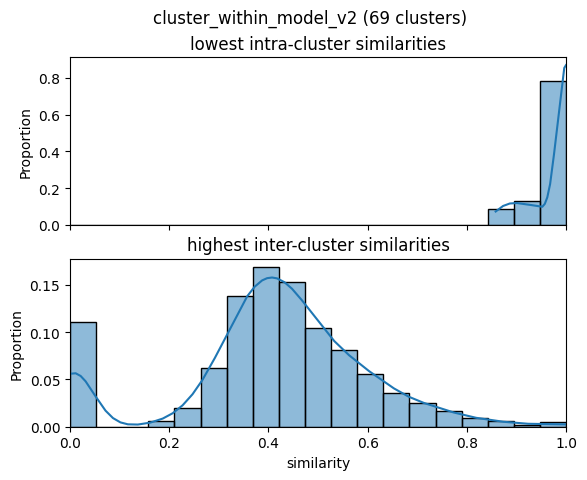

In [17]:
utils_analysis.judge_clustering(mc, "cluster_within_model_v2", show=True)

When you cluster motifs with respect to a similarity threshold, you will often find that the similarity threshold is not a hard constraint. That is, within clusters, you will find pairs of motifs whose similarity is below the similarity threshold, and between clusters, you will find pairs of motifs whose similarity is above the similarity threshold. It can be useful to visualize these "violations" of the similarity threshold to see how agregious or acceptable they are.

To do so, you can use the `plot_clustering_similarity_mismatch()` function in the analysis submodule.

This takes in a MotifCompendium, a clustering column name, a similarity threshold, and a path to save the resulting file to. Then, it produces a .html file with examples of when the clustering did not match with the similarity threshold. This function can also optionally take as input an argument called `max_examples`, which is the maximum number of mismatch examples to display. By default, `max_examples` is set to 100.

In [18]:
utils_analysis.plot_clustering_similarity_mismatch(mc, "cluster_within_model_v2", 0.85, "tutorial_outputs/similarity_mismatch.html")

The [similarity mismatch](https://mitra.stanford.edu/kundaje/oak/salil512/web/motif_compendium/tutorial_outputs/similarity_mismatch.html) shows examples of the clustering not meeting the expectations set by the similarity threshold.

# Part 3 - Available Clustering Algorithms

So far, we have not discussed the clustering algorithms available in MotifCompendium. In this section, we will discuss the options available to you, as well as the properties of each algorithm.

For the full documentation of all of the algorithms available for use, please refer to the `utils/clustering.py` file.

To specify which clustering algorithm you would like to use, you can provide the optional `algorithm` argument to the `.cluster()` method. The algorithms are:

- Leiden With RB+Configuration Quality Function: can be specified by setting `algorithm` to `"rb_leiden"`, `"mod_leiden"`, or `"modularity_leiden"`.
- Leiden With Constant Potts Quality Function: can be specified by setting `algorithm` to `"cpm"`, `"cpm_leiden"`, or `"constant_potts_leiden"`.
- Connected Components: can be specified by setting `algorithm` to `"cc"` or `"connected_components"`.
- Densely Connected Components: can be specified by setting `algorithm` to `"dcc"`, `"dense_cc"`, or `"densely_connected_components"`.
- Spectral Clustering: can be specified by setting `algorithm` to `"spectral"`.

If `algorithm` is not specified by the user, it defaults to `cpm_leiden`.

Each one of these algorithms has different optional arguments and properties, which we will discuss below.

## RB Leiden

RB Leiden is the Leiden community detection algorithm run with quality function being Reichardt and Bornholdt's Potts model with a configuration null model. Using this clustering algorithm calls the `RBConfigurationVertexPartition()` function of the `leidenalg` Python package in the back end. For more information about RB Leiden, please refer to the documentation of the underlying [leidenalg function](https://leidenalg.readthedocs.io/en/stable/reference.html#rbconfigurationvertexpartition).

When the RB Leiden algorithm is specified, the following optional arguments can be provided:

- `resolution_parameter`: A number that represents the resolution parameter used in the Leiden algorithm. Defaults to 1.0.
- `n_iterations`: The number of iterations that the Leiden algorithm runs. If set to -1, then Leiden will run until there is no longer any improvement in clustering quality. Defaults to -1. 2 is another commonly used value for this parameter.
- `seeds`: A list of seeds with which to run the Leiden algorithm with. For each seed in `seeds`, Leiden is run. The run with the best quality is used. Defaults to `[100, 200]`.

To clarify, the relationship between `seeds` and `n_iterations` is that for each `seed` in `seeds`, the Leiden algorithm is run. For each one of those runs, Leiden is allowed to run for `n_iterations` iterations.

Here is an example of how to use the RB Leiden algorithm:

In [19]:
mc.cluster(algorithm="rb_leiden", similarity_threshold=0.9, save_name="rb_leiden_test", resolution_parameter=0.8, n_iterations=2, seeds=[0, 1, 2])
mc

,name,num_seqlets,model,posneg,avg_contrib,avg_dist_from_summit,cluster,cluster_0.7,cluster_0.75,cluster_0.8,cluster_0.85,cluster_0.9,cluster_0.95,cluster_within_model,cluster_0.95_then_0.85,cluster_within_model_v2,weighted_cluster_0.95_then_0.85,cluster_within_model_v2_unordered,rb_leiden_test
0,cardiomyocyte-pos.pattern_0,24730,cardiomyocyte,pos,0.629150,15.721553,3,13,11,15,19,3,0,2,8,16,8,11,18
1,cardiomyocyte-pos.pattern_1,23251,cardiomyocyte,pos,0.421469,33.662853,8,8,6,5,6,8,1,1,4,4,4,9,8
2,cardiomyocyte-pos.pattern_10,4122,cardiomyocyte,pos,0.383973,33.419699,12,2,14,13,21,12,18,6,16,7,16,1,9
3,cardiomyocyte-pos.pattern_11,4008,cardiomyocyte,pos,0.351602,36.965818,4,14,13,14,20,4,19,3,15,3,15,10,10
4,cardiomyocyte-pos.pattern_12,3352,cardiomyocyte,pos,0.453516,42.597554,32,0,12,11,9,32,16,4,17,6,17,0,22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83,endothelial-pos.pattern_5,3338,endothelial,pos,0.479641,37.803475,1,1,1,1,2,1,6,82,0,2,0,35,0
84,endothelial-pos.pattern_6,2977,endothelial,pos,0.437019,35.074236,13,5,19,21,15,13,5,83,19,65,19,65,14
85,endothelial-pos.pattern_7,2358,endothelial,pos,0.469403,37.488550,16,11,15,16,17,16,8,84,18,66,18,66,15
86,endothelial-pos.pattern_8,2115,endothelial,pos,0.529135,51.907329,64,32,18,47,54,64,75,85,56,67,56,67,58


RB Leiden does not strictly adhere to similarity thresholds. For example, in the example above, despite using a similarity threshold of 0.9, there are clusters whose lowest internal similarity is below 0.9 and clusters whose highest external similarity is above 0.9.

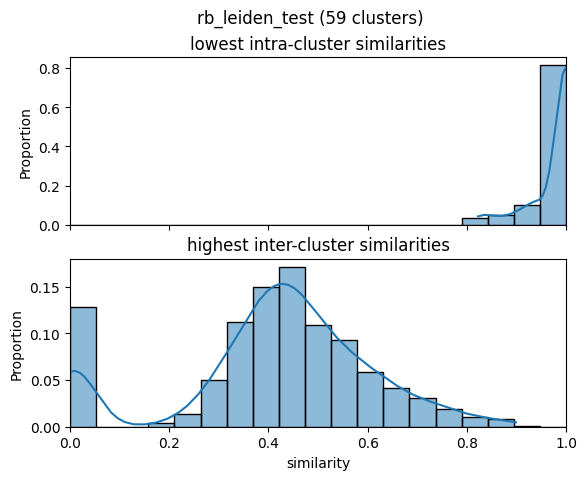

In [20]:
utils_analysis.judge_clustering(mc, "rb_leiden_test", show=True)

## CPM Leiden

CPM Leiden is the Leiden community detection algorithm run with the Constant Potts model quality function. Using this clustering algorithm calls the `CPMVertexPartition()` function of the `leidenalg` Python package in the back end. For more information about CPM Leiden, please refer to the documentation of the underlying [leidenalg function](https://leidenalg.readthedocs.io/en/stable/reference.html#cpmvertexpartition).

When the CPM Leiden algorithm is specified, the following optional arguments can be provided:

- `resolution_parameter`: A number that represents the resolution parameter used in the Leiden algorithm. Defaults to 1.0.
- `n_iterations`: The number of iterations that the Leiden algorithm runs. If set to -1, then Leiden will run until there is no longer any improvement in clustering quality. Defaults to -1. 2 is another commonly used value for this parameter.
- `seeds`: A list of seeds with which to run the Leiden algorithm with. For each seed in `seeds`, Leiden is run. The run with the best quality is used. Defaults to `[100, 200]`.

To clarify, the relationship between `seeds` and `n_iterations` is that for each `seed` in `seeds`, the Leiden algorithm is run. For each one of those runs, Leiden is allowed to run for `n_iterations` iterations.

Here is an example of how to use the CPM Leiden algorithm:

In [21]:
mc.cluster(algorithm="cpm_leiden", similarity_threshold=0.9, save_name="cpm_leiden_test", resolution_parameter=0.8, n_iterations=2, seeds=[0, 1, 2])
mc

,name,num_seqlets,model,posneg,avg_contrib,avg_dist_from_summit,cluster,cluster_0.7,cluster_0.75,cluster_0.8,cluster_0.85,cluster_0.9,cluster_0.95,cluster_within_model,cluster_0.95_then_0.85,cluster_within_model_v2,weighted_cluster_0.95_then_0.85,cluster_within_model_v2_unordered,rb_leiden_test,cpm_leiden_test
0,cardiomyocyte-pos.pattern_0,24730,cardiomyocyte,pos,0.629150,15.721553,3,13,11,15,19,3,0,2,8,16,8,11,18,18
1,cardiomyocyte-pos.pattern_1,23251,cardiomyocyte,pos,0.421469,33.662853,8,8,6,5,6,8,1,1,4,4,4,9,8,12
2,cardiomyocyte-pos.pattern_10,4122,cardiomyocyte,pos,0.383973,33.419699,12,2,14,13,21,12,18,6,16,7,16,1,9,11
3,cardiomyocyte-pos.pattern_11,4008,cardiomyocyte,pos,0.351602,36.965818,4,14,13,14,20,4,19,3,15,3,15,10,10,10
4,cardiomyocyte-pos.pattern_12,3352,cardiomyocyte,pos,0.453516,42.597554,32,0,12,11,9,32,16,4,17,6,17,0,22,24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83,endothelial-pos.pattern_5,3338,endothelial,pos,0.479641,37.803475,1,1,1,1,2,1,6,82,0,2,0,35,0,3
84,endothelial-pos.pattern_6,2977,endothelial,pos,0.437019,35.074236,13,5,19,21,15,13,5,83,19,65,19,65,14,15
85,endothelial-pos.pattern_7,2358,endothelial,pos,0.469403,37.488550,16,11,15,16,17,16,8,84,18,66,18,66,15,17
86,endothelial-pos.pattern_8,2115,endothelial,pos,0.529135,51.907329,64,32,18,47,54,64,75,85,56,67,56,67,58,60


CPM Leiden does not strictly adhere to similarity thresholds. For example, in the example above, despite using a similarity threshold of 0.9, there are clusters whose lowest internal similarity is below 0.9 and clusters whose highest external similarity is above 0.9.

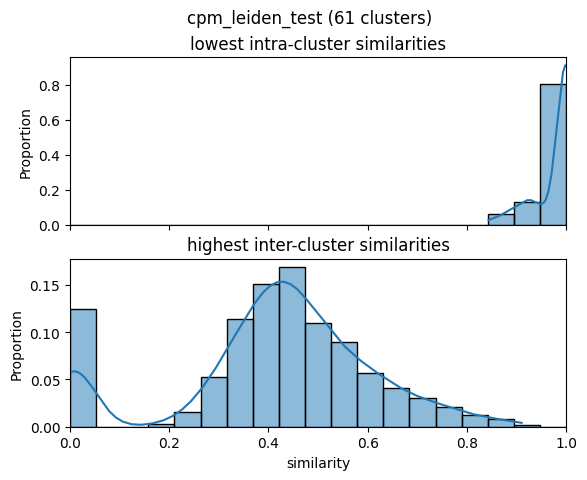

In [22]:
utils_analysis.judge_clustering(mc, "cpm_leiden_test", show=True)

## Connected Components

The connected components algorithm will cluster all motifs that are in a connected component together. Each connected component is defined as the set of all motifs that can reach one another by traversing the edges in the graph defined by the adjacency matrix derived by thresholding the similarity matrix by the similarity threshold. For more information about connected components, consider reading the [connected components Wikipedia article](https://en.wikipedia.org/wiki/Component_(graph_theory)).

Here is an example of how to use the connected components algorithm:

In [23]:
mc.cluster(algorithm="cc", similarity_threshold=0.95, save_name="cc_leiden_test_95")
mc

,name,num_seqlets,model,posneg,avg_contrib,avg_dist_from_summit,cluster,cluster_0.7,cluster_0.75,cluster_0.8,...,cluster_0.9,cluster_0.95,cluster_within_model,cluster_0.95_then_0.85,cluster_within_model_v2,weighted_cluster_0.95_then_0.85,cluster_within_model_v2_unordered,rb_leiden_test,cpm_leiden_test,cc_leiden_test_95
0,cardiomyocyte-pos.pattern_0,24730,cardiomyocyte,pos,0.629150,15.721553,3,13,11,15,...,3,0,2,8,16,8,11,18,18,0
1,cardiomyocyte-pos.pattern_1,23251,cardiomyocyte,pos,0.421469,33.662853,8,8,6,5,...,8,1,1,4,4,4,9,8,12,1
2,cardiomyocyte-pos.pattern_10,4122,cardiomyocyte,pos,0.383973,33.419699,12,2,14,13,...,12,18,6,16,7,16,1,9,11,18
3,cardiomyocyte-pos.pattern_11,4008,cardiomyocyte,pos,0.351602,36.965818,4,14,13,14,...,4,19,3,15,3,15,10,10,10,19
4,cardiomyocyte-pos.pattern_12,3352,cardiomyocyte,pos,0.453516,42.597554,32,0,12,11,...,32,16,4,17,6,17,0,22,24,16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83,endothelial-pos.pattern_5,3338,endothelial,pos,0.479641,37.803475,1,1,1,1,...,1,6,82,0,2,0,35,0,3,6
84,endothelial-pos.pattern_6,2977,endothelial,pos,0.437019,35.074236,13,5,19,21,...,13,5,83,19,65,19,65,14,15,5
85,endothelial-pos.pattern_7,2358,endothelial,pos,0.469403,37.488550,16,11,15,16,...,16,8,84,18,66,18,66,15,17,8
86,endothelial-pos.pattern_8,2115,endothelial,pos,0.529135,51.907329,64,32,18,47,...,64,75,85,56,67,56,67,58,60,75


The connected components algorithm has the useful property that it guarantees that the maximum inter-cluster similarity is upper bounded by the similarity threshold. That means that if any two motifs have a similarity higher than the similarity threshold, then you can guarantee that they will be in the same cluster. This can be helpful if you want to make sure that you are not overclustering and making multiple clusters that will need to be combined later. The weakness of this algorithm, however, is that there is no guaranteed lower bound to the lowest intra-cluster similarity. In theory, it is possible to have two motifs in a cluster that have 0 similarity.

Below, notice how when we use a 0.95 similarity threshold, the highest inter-cluster similarity is 0.95 but luckily the lowest intra-cluster similarity is also around 0.95.

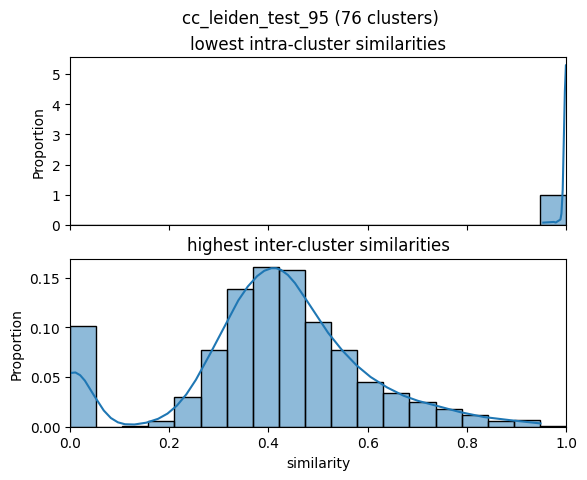

In [24]:
utils_analysis.judge_clustering(mc, "cc_leiden_test_95", show=True)

However, notice below how when we use a 0.90 similarity threshold, the highest inter-cluster similarity is still bounded above and is 0.90, but the lowest intra-cluster similarity drops well below our similarity threshold to be below 0.80.

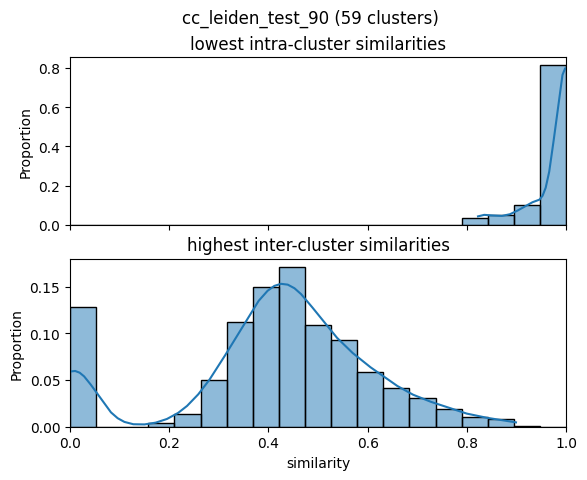

In [25]:
mc.cluster(algorithm="cc", similarity_threshold=0.90, save_name="cc_leiden_test_90")
utils_analysis.judge_clustering(mc, "cc_leiden_test_90", show=True)

For this reason, it is recommended to only use the connected components algorithm with high similarity thresholds. And, if you do use this algorithm, you may need to subcluster your clusters.

## Densely Connected Components

The densely connected components algorithm attempts to identify dense subgraphs in the graph defined by the adjacency matrix derived by thresholding the similarity matrix by the similarity threshold. It will attempt to find clusters of motifs whose pairwise similarity with each other is all higher than the similarity threshold.

It is important to note that the problem of finding densely connected components in a graph is not well-posed because, in general, there is not a unique partition of a graph into dense subgraphs. Depending on the initialization of the problem or the order in which motifs are considered, DCC may end up with different solutions. Because of this, the DCC algorithm is a seeded algorithm whose outcome will change based on the starting seed but is deterministic given a starting seed.

When the DCC algorithm is specified, the following optional arguments can be provided:

- `density`: A number in (0, 1] that specifies how dense the dense subgraphs need to be. This number represents the percent of edges that need to be in each cluster. The default value is `1`. When this is set to `1`, all clusters are fully dense subgraphs and for a cluster of `n` motifs, all $_nC_2=\frac{n(n-1)}{2}$ edges will be present. Otherwise, in general, for every cluster of `n` motifs, $density \times \frac{n(n-1)}{2}$ edges are present.
- `seed`: The seed to run the DCC algorithm with. The default seed is `1`.

Here is an example of how to use the densely connected components algorithm:

In [26]:
mc.cluster(algorithm="dcc", similarity_threshold=0.95, density=0.8, seed=10, save_name="dcc_leiden_test_95")
mc

,name,num_seqlets,model,posneg,avg_contrib,avg_dist_from_summit,cluster,cluster_0.7,cluster_0.75,cluster_0.8,...,cluster_within_model,cluster_0.95_then_0.85,cluster_within_model_v2,weighted_cluster_0.95_then_0.85,cluster_within_model_v2_unordered,rb_leiden_test,cpm_leiden_test,cc_leiden_test_95,cc_leiden_test_90,dcc_leiden_test_95
0,cardiomyocyte-pos.pattern_0,24730,cardiomyocyte,pos,0.629150,15.721553,3,13,11,15,...,2,8,16,8,11,18,18,0,18,0
1,cardiomyocyte-pos.pattern_1,23251,cardiomyocyte,pos,0.421469,33.662853,8,8,6,5,...,1,4,4,4,9,8,12,1,8,1
2,cardiomyocyte-pos.pattern_10,4122,cardiomyocyte,pos,0.383973,33.419699,12,2,14,13,...,6,16,7,16,1,9,11,18,9,18
3,cardiomyocyte-pos.pattern_11,4008,cardiomyocyte,pos,0.351602,36.965818,4,14,13,14,...,3,15,3,15,10,10,10,19,10,19
4,cardiomyocyte-pos.pattern_12,3352,cardiomyocyte,pos,0.453516,42.597554,32,0,12,11,...,4,17,6,17,0,22,24,16,22,16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83,endothelial-pos.pattern_5,3338,endothelial,pos,0.479641,37.803475,1,1,1,1,...,82,0,2,0,35,0,3,6,0,6
84,endothelial-pos.pattern_6,2977,endothelial,pos,0.437019,35.074236,13,5,19,21,...,83,19,65,19,65,14,15,5,14,5
85,endothelial-pos.pattern_7,2358,endothelial,pos,0.469403,37.488550,16,11,15,16,...,84,18,66,18,66,15,17,8,15,8
86,endothelial-pos.pattern_8,2115,endothelial,pos,0.529135,51.907329,64,32,18,47,...,85,56,67,56,67,58,60,75,58,75


The densely connected components algorithm has the useful property that it guarantees that the minimum intra-cluster similarity is lower bounded by the similarity threshold. That means that you can guarantee that the lowest similarity between any two motifs that are in the same cluster will be higher than the similarity threshold. This can be helpful if want to enforce that your clusters are sufficiently homogenous. The weakness of this algorithm, however, is that there is no guaranteed upper bound on the highest inter-cluster similarity. In possible, it is possible to have two motifs that have a similarity of 1 but have been assigned to different clusters.

Below, notice how when we use a 0.95 similarity threshold, the lowest intra-cluster similarity is 0.95 but luckily the highest inter-cluster similarity is also around 0.95.

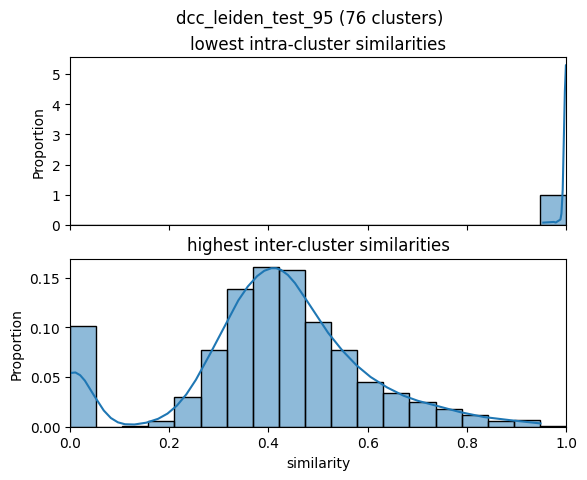

In [27]:
utils_analysis.judge_clustering(mc, "dcc_leiden_test_95", show=True)

However, notice below how when we use a 0.90 similarity threshold, the lowest intra-cluster similarity is still bounded below and is 0.90, but the highest inter-cluster similarity rises well above our similarity threshold to around 0.97.

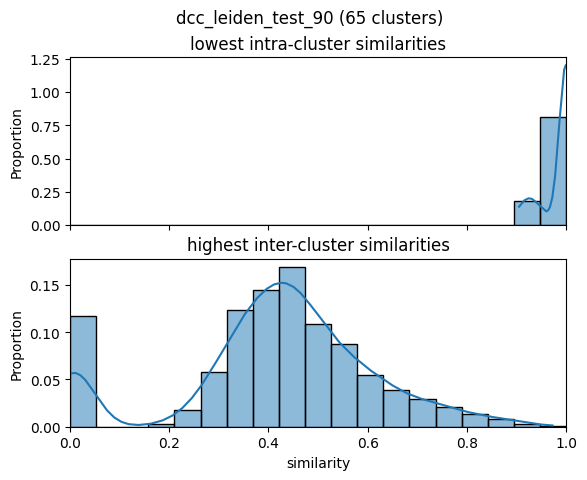

In [28]:
mc.cluster(algorithm="dcc", similarity_threshold=0.90, save_name="dcc_leiden_test_90")
utils_analysis.judge_clustering(mc, "dcc_leiden_test_90", show=True)

The densely connected components algorithm is helpful to use when you want to guarantee certain levels of homogeneity within your clusters. However, when you use it, expect that you may need to later merge clusters which have been overclustered.

## Spectral Clustering

Spectral clustering is a clustering algorithm that uses the spectral structure of a similarity matrix to cluster nodes. Spectral clustering is very appropriate algorithm for clustering based on similarity information, but one drawback is that you have to specify the number of clusters you are looking for. Using this clustering algorithm calls the `cluster.SpectralClustering()` function of the `sklearn` Python package in the back end. For more information about spectral clustering, consider reading the [spectral clustering Wikipedia article](https://en.wikipedia.org/wiki/Spectral_clustering).

Unlike the other clustering algorithms, the `similarity_threshold` does not play a role during spectral clustering.

When the spectral clustering algorithm is specified, the following optional arguments can be provided:

- `k`: An integer representing the number of clusters to cluster the motifs into. Defaults to `40`.
- `cluster_qr`: Whether or not to use a QR factorization strategy to assign clusters. See [the original paper](https://academic.oup.com/imaiai/article/8/1/181/5045955) for more information. This defaults to `False`.

Here is an example of how to use the spectral clustering algorithm:

In [29]:
mc.cluster(algorithm="spectral", k=40, cluster_qr=True, save_name="spectral_test")
mc

,name,num_seqlets,model,posneg,avg_contrib,avg_dist_from_summit,cluster,cluster_0.7,cluster_0.75,cluster_0.8,...,cluster_within_model_v2,weighted_cluster_0.95_then_0.85,cluster_within_model_v2_unordered,rb_leiden_test,cpm_leiden_test,cc_leiden_test_95,cc_leiden_test_90,dcc_leiden_test_95,dcc_leiden_test_90,spectral_test
0,cardiomyocyte-pos.pattern_0,24730,cardiomyocyte,pos,0.629150,15.721553,3,13,11,15,...,16,8,11,18,18,0,18,0,3,13
1,cardiomyocyte-pos.pattern_1,23251,cardiomyocyte,pos,0.421469,33.662853,8,8,6,5,...,4,4,9,8,12,1,8,1,8,3
2,cardiomyocyte-pos.pattern_10,4122,cardiomyocyte,pos,0.383973,33.419699,12,2,14,13,...,7,16,1,9,11,18,9,18,12,14
3,cardiomyocyte-pos.pattern_11,4008,cardiomyocyte,pos,0.351602,36.965818,4,14,13,14,...,3,15,10,10,10,19,10,19,4,15
4,cardiomyocyte-pos.pattern_12,3352,cardiomyocyte,pos,0.453516,42.597554,32,0,12,11,...,6,17,0,22,24,16,22,16,32,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83,endothelial-pos.pattern_5,3338,endothelial,pos,0.479641,37.803475,1,1,1,1,...,2,0,35,0,3,6,0,6,1,0
84,endothelial-pos.pattern_6,2977,endothelial,pos,0.437019,35.074236,13,5,19,21,...,65,19,65,14,15,5,14,5,14,9
85,endothelial-pos.pattern_7,2358,endothelial,pos,0.469403,37.488550,16,11,15,16,...,66,18,66,15,17,8,15,8,16,25
86,endothelial-pos.pattern_8,2115,endothelial,pos,0.529135,51.907329,64,32,18,47,...,67,56,67,58,60,75,58,75,64,39


# Part 4 - Working With Clustered Motifs

One common thing that may happen when you cluster motifs is that you will want to compare and analyze your motif clusters. In such cases, it will be helpful to create a MotifCompendium of cluster-average motifs. That is, create a MotifCompendium of motifs where each motif is the average of all constituent motifs in a cluster.

This can be done by calling the `.cluster_averages()` method of a MotifCompendium object and providing it with the metadata column name that has cluster annotations that you would like to aggregate.

Below, we will cluster our MotifCompendium on the `dcc_leiden_test_95` column. Notice how the size of the cluster-averaged MotifCompendium is exactly the same as the number of clusters in the original MotifCompendium.

In [30]:
print(f"Number of clusters in dcc_leiden_test_95: {len(set(mc['dcc_leiden_test_95']))}")
mc_avg = mc.cluster_averages("dcc_leiden_test_95")
mc_avg

Number of clusters in dcc_leiden_test_95: 76


,name,source_cluster,num_constituents
0,dcc_leiden_test_95#0,0,2
1,dcc_leiden_test_95#1,1,2
2,dcc_leiden_test_95#2,2,2
3,dcc_leiden_test_95#3,3,2
4,dcc_leiden_test_95#4,4,2
...,...,...,...
71,dcc_leiden_test_95#71,71,1
72,dcc_leiden_test_95#72,72,1
73,dcc_leiden_test_95#73,73,1
74,dcc_leiden_test_95#74,74,1


Notice how there are already some columns populated in the metadata. The `name` column has a pre-assigned name for each motif cluster; this name is of the format `{clustering_name}#{cluster ID}`. The `source_cluster` column contains the cluster IDs that were in the specified metadata column. And `num_constituents` has the number of motifs per cluster. 

In general, there are many other columns you may want to include in your `metadata` that summarize various characteristics of a motif cluster. For example, you may want to compute the total number of seqlets contributing to a cluster, or figure out which celltypes motifs in the cluster came from.

The `.cluster_averages()` method has an optional `aggregations` argument which can help you automatically populate your cluster-averaged `metadata` based on the information in the original `metadata`. The `aggregations` argument is specified as a list of tuples of length 3. Each tuple specifies a particular aggregation you would like to perform during clustering. By providing multiple tuples in the `aggregations` list, you are defining multiple aggregations to perform.

Each tuple is of the form `(source, method, save)`. The first element of the tuple, called `source`, is a column in the original `metadata` that will be used to perform the aggregations. The third element of the tuple, called `save`, is the name of the column in the cluster-averaged `metadata` into which the aggregation information will be stored. And the second element of the tuple, called `method`, declares the type of aggregation that you would like performed on the `source` metadata column. The `method` must be a string chosen from one of the following options:

- `"count"`: This option counts the number of values in the source column for each cluster.
- `"unique"`: This option counts the number of unique values in the source column for each cluster.
- `"sum"`: This option sums the values in the source column for each cluster.
- `"average"` or `"avg"` or `"mean"`: This option averages the values in the source column for each cluster.
- `"concatenate"` or `"concat"`: This option lists all the unique values in the source column for each cluster.
- `"concat_counted"`: This option lists all the unique values and their number of occurrences in the source column for each cluster.

The default value of the `aggregations` argument is `[("name", "count", "num_constituents")]`. This means that by default, a single aggregation that counts the number of motifs in each cluster and saves it to a column called `num_constituents` is performed. The `num_constituents` column in the example above is generated in this manner. If you don't want to perform any aggregations, set `aggregations` to an empyty list, `[]`. Even in that case, though, the `name` and `source_cluster` column of the cluster-averaged MotifCompendium will be automatically populated.

Let us look at some examples of how one can use the `aggregations` argument.

- Suppose I want to see the celltypes that motifs that make up a cluster come from. This can be performed with the aggregation `("model", "concat", "source_models")`. When used on the example MotifCompendium, the `source_models` column will have values like `cardiomyocyte`, `endothelial`, or `cardiomyocyte,endothelial`.
- Suppose I want a count of how many celltypes motifs that make up a cluster come from. This can be performed with the aggregation `("model", "unique", "num_models")`. When used on the example MotifCompendium, the `num_models` column will have values like `1` and `2`.
- Suppose I want to see how many motifs came from each celltype in a cluster. This can be performed with the aggregation `("model", "concat_counted", "motifs_per_model")`. When used on the example MotifCompendium, the `motifs_per_model` column will have values like `cardiomyocyte (2)` and `cardiomyocyte(1),endothelial(1)`.
- Suppose I want to count the total number of seqlets contributing to each cluster across their various constituent motifs. This can be performed with the aggregation `("num_seqlets", "sum", "total_seqlets")`.
- Suppose I want to compute the average distance from peak summits across all motifs in a cluster. This can be performed with the aggregation `("avg_dist_from_summit", "avg", "avg_dist_from_summit")`.

Let's perform another cluster average and specify all of these aggregations.

In [31]:
mc_avg = mc.cluster_averages("dcc_leiden_test_95", aggregations=[("name", "count", "num_constituents"),
                                                                 ("model", "concat", "source_models"),
                                                                 ("model", "unique", "num_models"),
                                                                 ("model", "concat_counted", "motifs_per_model"),
                                                                 ("num_seqlets", "sum", "total_seqlets"),
                                                                 ("avg_dist_from_summit", "avg", "avg_dist_from_summit")])
mc_avg

,name,source_cluster,num_constituents,source_models,num_models,motifs_per_model,total_seqlets,avg_dist_from_summit
0,dcc_leiden_test_95#0,0,2,"cardiomyocyte,endothelial",2,"cardiomyocyte (1),endothelial (1)",38476,16.033408
1,dcc_leiden_test_95#1,1,2,"cardiomyocyte,endothelial",2,"cardiomyocyte (1),endothelial (1)",29095,37.674000
2,dcc_leiden_test_95#2,2,2,"cardiomyocyte,endothelial",2,"cardiomyocyte (1),endothelial (1)",3062,44.632288
3,dcc_leiden_test_95#3,3,2,"cardiomyocyte,endothelial",2,"cardiomyocyte (1),endothelial (1)",4463,41.164720
4,dcc_leiden_test_95#4,4,2,endothelial,1,endothelial (2),25334,41.311680
...,...,...,...,...,...,...,...,...
71,dcc_leiden_test_95#71,71,1,endothelial,1,endothelial (1),3695,44.521245
72,dcc_leiden_test_95#72,72,1,endothelial,1,endothelial (1),23,53.347826
73,dcc_leiden_test_95#73,73,1,endothelial,1,endothelial (1),22,43.545455
74,dcc_leiden_test_95#74,74,1,endothelial,1,endothelial (1),21,37.571429


The `aggregations` argument can help you automate some of the work of computing per-cluster information on a motif-averaged cluster. However, the types of aggregations that can be automated is limited to the `method` options described above. In general, you may need to perform your own aggregations. Here is a code pattern that can be used to perform aggregations. First, we will manually compute the `num_constituents` information.

In [32]:
# Create cluster-averaged MotifCompendium
mc_avg_noaggr = mc.cluster_averages("dcc_leiden_test_95", aggregations=[])
# Compute aggregations manually
num_constituents = []
for cluster_id in mc_avg_noaggr["source_cluster"]:
    num_constituents.append(len(mc[mc["dcc_leiden_test_95"] == cluster_id]))
mc_avg_noaggr["num_constituents"] = num_constituents
mc_avg_noaggr

,name,source_cluster,num_constituents
0,dcc_leiden_test_95#0,0,2
1,dcc_leiden_test_95#1,1,2
2,dcc_leiden_test_95#2,2,2
3,dcc_leiden_test_95#3,3,2
4,dcc_leiden_test_95#4,4,2
...,...,...,...
71,dcc_leiden_test_95#71,71,1
72,dcc_leiden_test_95#72,72,1
73,dcc_leiden_test_95#73,73,1
74,dcc_leiden_test_95#74,74,1


Now, we will use the same pattern to compute a more complicated quantity like the GC content of the motifs in the cluster.

In [33]:
# Create cluster-averaged MotifCompendium
mc_avg_noaggr = mc.cluster_averages("dcc_leiden_test_95", aggregations=[])
# Compute aggregations manually
gc_content = []
for cluster_id in mc_avg_noaggr["source_cluster"]:
    mc_cluster = mc[mc["dcc_leiden_test_95"] == cluster_id]
    cluster_motifs = mc_cluster.get_standard_motif_stack()
    cluster_motifs_abs = np.abs(cluster_motifs) # Get absolute values to look at per-base contribution
    gc = np.sum(cluster_motifs_abs[:, :, 1:3])/np.sum(cluster_motifs_abs)
    gc_content.append(gc)
mc_avg_noaggr["gc_content"] = gc_content
mc_avg_noaggr

,name,source_cluster,gc_content
0,dcc_leiden_test_95#0,0,0.831157
1,dcc_leiden_test_95#1,1,0.841753
2,dcc_leiden_test_95#2,2,0.621856
3,dcc_leiden_test_95#3,3,0.852843
4,dcc_leiden_test_95#4,4,0.664950
...,...,...,...
71,dcc_leiden_test_95#71,71,0.307085
72,dcc_leiden_test_95#72,72,0.627496
73,dcc_leiden_test_95#73,73,0.324940
74,dcc_leiden_test_95#74,74,0.631627


With this pattern, we were able to compute the GC content for each cluster. Let's sort by the `gc_content` column to find the motif with the highest GC content!

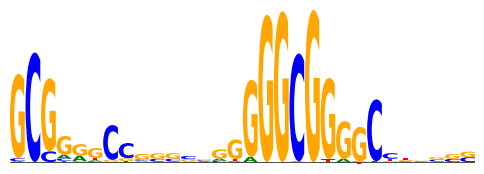

In [34]:
most_gc_cluster = mc_avg_noaggr.sort("gc_content", ascending=False).get_standard_motif_stack()[0]
utils_plotting.plot_motif(most_gc_cluster, show=True)

When motifs are averaged, by default, they are all weighted equally. However, in some cases, one may want to take a weighted average of motifs in a cluster. For example, one may want to weight each motif by its number of constituent seqlets. By specifying the `weight_col` argument, the `.cluster_averages()` method can take weighted averages of motifs. The `weight_col` argument takes in any column name that will be interpreted as a numerical weighting on each motif. Below, let's take a seqlet-weighted average.

In [35]:
weighted_mc_avg = mc.cluster_averages("dcc_leiden_test_95", weight_col="num_seqlets", aggregations=[("name", "count", "num_constituents"),
                                                                                           ("model", "concat", "source_models"),
                                                                                           ("model", "unique", "num_models"),
                                                                                           ("model", "concat_counted", "motifs_per_model"),
                                                                                           ("num_seqlets", "sum", "total_seqlets"),
                                                                                           ("avg_dist_from_summit", "avg", "avg_dist_from_summit")])
weighted_mc_avg

,name,source_cluster,num_constituents,source_models,num_models,motifs_per_model,total_seqlets,avg_dist_from_summit
0,dcc_leiden_test_95#0,0,2,"cardiomyocyte,endothelial",2,"cardiomyocyte (1),endothelial (1)",38476,16.033408
1,dcc_leiden_test_95#1,1,2,"cardiomyocyte,endothelial",2,"cardiomyocyte (1),endothelial (1)",29095,37.674000
2,dcc_leiden_test_95#2,2,2,"cardiomyocyte,endothelial",2,"cardiomyocyte (1),endothelial (1)",3062,44.632288
3,dcc_leiden_test_95#3,3,2,"cardiomyocyte,endothelial",2,"cardiomyocyte (1),endothelial (1)",4463,41.164720
4,dcc_leiden_test_95#4,4,2,endothelial,1,endothelial (2),25334,41.311680
...,...,...,...,...,...,...,...,...
71,dcc_leiden_test_95#71,71,1,endothelial,1,endothelial (1),3695,44.521245
72,dcc_leiden_test_95#72,72,1,endothelial,1,endothelial (1),23,53.347826
73,dcc_leiden_test_95#73,73,1,endothelial,1,endothelial (1),22,43.545455
74,dcc_leiden_test_95#74,74,1,endothelial,1,endothelial (1),21,37.571429


Note that performing a weighted average only changes the motifs in the cluster-averaged MotifCompendium. It does not change the way that any aggregations are performed. If you would like to perform weighted aggregations, consider performing those aggregations manually as described above.

The `.cluster_averages()` method also has an optional argument called `compute_quality_stats`. `compute_quality_stats` is a boolean that when set to `True` saves additional columns in the metadata of the cluster-averaged MotifCompendium that summarize the quality of the clustering. Logos that help visualize the quality of the clusters are also saved as additional images in the MotifCompendium.

In [36]:
mc_avg = mc.cluster_averages("dcc_leiden_test_95", compute_quality_stats=True, aggregations=[("name", "count", "num_constituents"),
                                                                                             ("model", "concat", "source_models"),
                                                                                             ("model", "unique", "num_models"),
                                                                                             ("model", "concat_counted", "motifs_per_model"),
                                                                                             ("num_seqlets", "sum", "total_seqlets"),
                                                                                             ("avg_dist_from_summit", "avg", "avg_dist_from_summit")])
mc_avg

,name,source_cluster,num_constituents,source_models,num_models,motifs_per_model,total_seqlets,avg_dist_from_summit,best_match_similarity,lowest_internal_similarity,highest_external_similarity
0,dcc_leiden_test_95#0,0,2,"cardiomyocyte,endothelial",2,"cardiomyocyte (1),endothelial (1)",38476,16.033408,0.621 (dcc_leiden_test_95#7),0.998 (cardiomyocyte-pos.pattern_0 vs endothel...,0.626 (13: cardiomyocyte-pos.pattern_18)
1,dcc_leiden_test_95#1,1,2,"cardiomyocyte,endothelial",2,"cardiomyocyte (1),endothelial (1)",29095,37.674000,0.864 (dcc_leiden_test_95#38),0.994 (cardiomyocyte-pos.pattern_1 vs endothel...,0.87 (38: cardiomyocyte-pos.pattern_39)
2,dcc_leiden_test_95#2,2,2,"cardiomyocyte,endothelial",2,"cardiomyocyte (1),endothelial (1)",3062,44.632288,0.73 (dcc_leiden_test_95#66),0.995 (cardiomyocyte-pos.pattern_17 vs endothe...,0.734 (66: endothelial-pos.pattern_35)
3,dcc_leiden_test_95#3,3,2,"cardiomyocyte,endothelial",2,"cardiomyocyte (1),endothelial (1)",4463,41.164720,0.949 (dcc_leiden_test_95#27),0.999 (cardiomyocyte-pos.pattern_15 vs endothe...,0.949 (27: cardiomyocyte-pos.pattern_20)
4,dcc_leiden_test_95#4,4,2,endothelial,1,endothelial (2),25334,41.311680,0.91 (dcc_leiden_test_95#55),0.954 (endothelial-pos.pattern_0 vs endothelia...,0.912 (55: endothelial-pos.pattern_21)
...,...,...,...,...,...,...,...,...,...,...,...
71,dcc_leiden_test_95#71,71,1,endothelial,1,endothelial (1),3695,44.521245,0.934 (dcc_leiden_test_95#73),1.0 (endothelial-pos.pattern_4 vs endothelial-...,0.934 (73: endothelial-pos.pattern_41)
72,dcc_leiden_test_95#72,72,1,endothelial,1,endothelial (1),23,53.347826,0.863 (dcc_leiden_test_95#4),1.0 (endothelial-pos.pattern_40 vs endothelial...,0.866 (4: endothelial-pos.pattern_0)
73,dcc_leiden_test_95#73,73,1,endothelial,1,endothelial (1),22,43.545455,0.934 (dcc_leiden_test_95#71),1.0 (endothelial-pos.pattern_41 vs endothelial...,0.934 (71: endothelial-pos.pattern_4)
74,dcc_leiden_test_95#74,74,1,endothelial,1,endothelial (1),21,37.571429,0.629 (dcc_leiden_test_95#8),1.0 (endothelial-pos.pattern_42 vs endothelial...,0.625 (8: cardiomyocyte-pos.pattern_9)


The additional columns are:

- `best_match_similarity`: specifies the most similar cluster.
- `lowest_internal_similarity`: specifies the two motifs in the cluster that have the lowest internal similarity.
- `highest_external_similarity`: specifies the motif in an external cluster that has the highest similarity with a motif in this cluster.

And, the following images are added:
- `best_match_cluster`: the logo of the best matching cluster (corresponds to the `best_match_similarity` column).
- `lowest_internal_similarity_motif1` and `lowest_internal_similarity_motif2`: the logos of the two motifs in the cluster that have the lowest internal similarity (corresponds to the `lowest_internal_similarity` column).
- `highest_external_similarity_motif` and `highest_external_similarity_cluster`: the logo of the external motif and the cluster it belongs to, respectively, that have the highest similarity to a motif in this cluster (corresponds to the `highest_external_similarity` column).

These columns and images are best visualized in a summary table.

In [37]:
mc_avg.summary_table_html("tutorial_outputs/motif_clusters_summary_with_quality.html", columns=["name", "source_cluster", "num_constituents", "source_models", "num_models",
                                                                                                "motifs_per_model", "total_seqlets", "avg_dist_from_summit",
                                                                                                "best_match_similarity", "best_match_cluster",
                                                                                                "lowest_internal_similarity", "lowest_internal_similarity_motif1", "lowest_internal_similarity_motif2",
                                                                                                "highest_external_similarity", "highest_external_similarity_cluster", "highest_external_similarity_motif"])

The [summary table of motif clusters](https://mitra.stanford.edu/kundaje/oak/salil512/web/motif_compendium/tutorial_outputs/motif_clusters_summary_with_quality.html) can help tell you about the quality of your clustering and the steps you may want to take afterwards to improve the clustering.

If the `best_match_similarity` is too high and the `best_match_cluster` looks too similar to a cluster's logo, then it may be that the two clusters need to be merged. If you are seeing this constiently across all the clusters, then you may have overclustered and may want to either perform a second round of clustering on top of this or decrease the similarity threshold and recluster everything.

If the `lowest_internal_similarity` is too low and `lowest_internal_similarity_motif1` and `lowest_internal_similarity_motif2` look too different, it may be that the cluster is not homogenous and needs to be broken up. If you are seeing this consistently across all the clusters, then you may have underclustered and may want to increase the similarity threshold and recluster everything.

If the `highest_external_similarity` is too high, then you should look at the `highest_external_similarity_cluster` and `highest_external_similarity_motif` to diagnose the cause. If the `highest_external_similarity_motif` looks like the `highest_external_similarity_cluster`, and they both look like the cluster logo, then it may be that the two clusters need to be merged. If the `highest_external_similarity_motif` looks like the cluster logo but the `highest_external_similarity_cluster` does not, then it may mean that the external cluster is not homogenous and has a motif that belongs in the current cluster, and you may want to increase the similarity threshold and recluster everything. Similarly, if the `highest_external_similarity_motif` looks like the `highest_external_similarity_cluster` but neither of them look like the cluster logo, then it may indicate that the cluster you are looking at is not homogenous and has a motif that belongs in the external cluster, and that you may want to increase the similarity threshold and recluster everything.

# Part 5 - Conclusion

This tutorial describes the all the details of how motif clustering can be performed, how to judge the quality of a clustering, and how to work with cluster-averaged motifs downstream of clustering. These steps are all very central to the work one may do with motifs, and learning how to properly cluster motifs can help ensure the fidelity of downstream work and conclusions.

The `utils/clustering.py` module can be used on its own to perform any of the clustering algorithms available in MotifCompendium. If you need to use, modify, or extend any of the core clustering algorithms in MotifCompendium, please refer to `utils/clustering.py`.

Thank you so much for trying out MotifCompendium!